# Discount Fever
The analysis below explores a dataset showing discount code usage against sales data for a time period between 2024-2025. Through analysis, we determine that discount codes are driving revenue volume while targeting audience segments, calendar moments, and product categories. I believe careful monitoring is needed to ensure discounting doesn't undermine profit margins.

The data shows:
* Discounted orders consistently account for higher sales volume.
* Revenue remains strong despite large total discounts, indicating smart bundling or effective cross-sells.
* 2024 discount activity is higher in Q1 and Q4, suggesting seasonal targeting.
* A small group of codes and titles account for most discount-driven revenue, reinforcing the power of targeted campaigns.
* Some anomalies (e.g., high discount amounts with little revenue effect [LIBRARY40/BASKET40]) need further review.

### Loading data into pandas dataframe and quick cleaning of column names.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

disc = pd.read_csv("2024-25 Discount Code Usage.csv")

In [2]:
print(disc.info())
disc.columns = disc.columns.str.strip().str.replace(" ", "_")
disc.columns = disc.columns.str.lower()
print(disc.columns.to_list())

<class 'pandas.DataFrame'>
RangeIndex: 11369 entries, 0 to 11368
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                11369 non-null  str    
 1   Discount Year       11369 non-null  int64  
 2   Discount Code 1     5647 non-null   str    
 3   Product Title       11369 non-null  str    
 4   Gross Sales         11369 non-null  float64
 5   Discounts           11369 non-null  float64
 6   Returns             11369 non-null  float64
 7   Net Sales           11369 non-null  float64
 8   Taxes               11369 non-null  float64
 9   Shipping            5679 non-null   float64
 10  Total Sales         11369 non-null  float64
 11  Net Quantity        11369 non-null  int64  
 12  Shopify Fee         10968 non-null  float64
 13  Net Received        10968 non-null  float64
 14  Discount Code used  11369 non-null  str    
dtypes: float64(9), int64(2), str(4)
memory usage: 1.7 MB
None
['date

In [3]:
# Ensuring the date column is in datetime format.
disc["date"] = pd.to_datetime(disc["date"], errors="coerce")

### Anonymization
For anonymity, I'll randomize title info in this dataset using native Python libraries.

In [4]:
import random
import hashlib
import string

def random_title(title):
    seed = int(hashlib.md5(str(title).encode()).hexdigest(), 16)
    rng = random.Random(seed)  # private RNG, seeded by the title
    words = str(title).split()
    result = []
    for word in words:
        rand_word = ''.join(rng.choice(string.ascii_lowercase) for _ in word)
        result.append(rand_word)
    return ' '.join(result)

unique_titles = disc["product_title"].dropna().unique()
title_map = {t: random_title(t) for t in unique_titles}

disc["product_title_anon"] = disc["product_title"].map(title_map)

In [5]:
# Overwriting proprietary titles with anonymized title information.
disc["product_title"] = disc["product_title_anon"]
disc = disc.drop(columns=["product_title_anon"])
disc.head()

,date,discount_year,discount_code_1,product_title,gross_sales,discounts,returns,net_sales,taxes,shipping,total_sales,net_quantity,shopify_fee,net_received,discount_code_used
0,2024-01-01,2024,NaN,hwowav,40.00,0.0,0.00,40.00,0.00,NaN,40.00,1,1.63,38.37,NO
1,2024-01-01,2024,NaN,oqcjyt fm frhvcbop,28.00,0.0,0.00,28.00,0.00,NaN,28.00,1,1.29,26.71,NO
2,2024-01-01,2024,NaN,ken tszunm,24.99,0.0,0.00,24.99,0.00,NaN,24.99,1,1.20,23.79,NO
3,2024-01-01,2024,NaN,xenfkntedeeysszl zih ujokxcre,24.99,0.0,-24.99,0.00,0.00,NaN,0.00,0,0.00,0.00,NO
4,2024-01-01,2024,NaN,jzc byjpeefy bowt fhphe vyshkk,17.00,0.0,0.00,17.00,1.74,NaN,18.74,1,1.03,17.71,NO


In [6]:
# Checking the anonymizer worked.
disc["product_title"].value_counts().head(10)

product_title
nampee zghya                    858
avg adhli uucro je ljcjb        235
qyidux jrtbrloxgh               214
rhdk gjipgyp fe ceetr pknbev    131
txe xhc zz uui oao gfwelkef     125
bwfor djlpycrk ekli fbbf        108
gxlnxk rvd                      106
dgc ardj rpyrpsuv               104
qgjakss vghy obbjzk             101
blxnxg totcdp fvbi               98
Name: count, dtype: int64

In [7]:
disc["discount_code_used"].value_counts(normalize=True)

discount_code_used
NO     0.503298
YES    0.496702
Name: proportion, dtype: float64

In [8]:
# Discount code usage count
discount_usage = disc["discount_code_used"].value_counts()

# Top 10 product count
top_products = disc["product_title"].value_counts().head(10)

# Average Discount by discount code
discount_average = disc.groupby("discount_code_used")["discounts"].mean().sort_values(ascending=False)

# Average Discount by code name
average_code = disc.groupby("discount_code_1")["discounts"].mean().sort_values(ascending=True)

# Total Sales by Discount Code
total_sales_by_code = disc.groupby('discount_code_used')['total_sales'].sum().sort_values(ascending=False)

print(discount_usage, top_products, discount_average, average_code, total_sales_by_code)

discount_code_used
NO     5722
YES    5647
Name: count, dtype: int64 product_title
nampee zghya                    858
avg adhli uucro je ljcjb        235
qyidux jrtbrloxgh               214
rhdk gjipgyp fe ceetr pknbev    131
txe xhc zz uui oao gfwelkef     125
bwfor djlpycrk ekli fbbf        108
gxlnxk rvd                      106
dgc ardj rpyrpsuv               104
qgjakss vghy obbjzk             101
blxnxg totcdp fvbi               98
Name: count, dtype: int64 discount_code_used
NO     -0.021992
YES   -51.534455
Name: discounts, dtype: float64 discount_code_1
AUTHOR60        -293.369683
AUTHOR75        -260.551786
HIGHGLOSS50     -250.000000
WINTEREATS      -184.995000
COOKOUT40        -91.630417
MILLERKNOLL24    -53.333333
KAPPADELTA       -42.000000
PILLOWY40        -40.000000
JCK2024          -36.666667
ABRFAM75         -32.684706
FESTIVE24        -25.472084
THESLOWDOWN24    -25.000000
HNAB60           -24.130168
NBCSNL           -22.916667
READWITHMOM      -20.265455
SPRING50  

### Discount Code Usage
Discount Code Usage \
Used: 5,647 transactions (YES) \
Not Used: 5,722 transactions (NO) \
There is a *roughly* 50/50 split of discount code usage with no discount code usage slightly winning at 50.33%. 

Total Sales\
With Discount Code (YES): $244,009.83\
Without Discount Code (NO): $221,191.99\
Despite heavy discounting, orders using codes brought in more revenue overall, likely due to higher volumes or larger baskets.

### Top 10 Best-Selling Products
#1: nampee zghya (858 sales, *anonymized*)\
Followed by avg adhli uucro je ljcjb, qyidux jrtbrloxgh, rhdk gjipgyp fe ceetr pknbev, etc (*all anonymized*).\
These top products might be good candidates for future promotions or bundling strategies

In [9]:
revenue_metrics = disc.groupby("discount_code_used")[["gross_sales", "discounts", "net_sales", "total_sales", "net_received"]].agg(["mean", "sum"])
qty_by_group = disc.groupby("discount_code_used")["net_quantity"].sum()
print(revenue_metrics, qty_by_group)

                   gross_sales             discounts             net_sales  \
                          mean        sum       mean        sum       mean   
discount_code_used                                                           
NO                   38.481346  220190.26  -0.021992    -125.84  37.094803   
YES                  93.625376  528702.50 -51.534455 -291015.07  41.471342   

                              total_sales            net_received             
                          sum        mean        sum         mean        sum  
discount_code_used                                                            
NO                  212256.46   38.656412  221191.99    37.137339  202621.32  
YES                 234188.67   43.210524  244009.83    41.045056  226240.35   discount_code_used
NO      7161
YES    17344
Name: net_quantity, dtype: int64


### Revenue Effects
Total quantity sold with a discount is 17,344 units while units sold without a discount is 7,161. That is less than half the units sold with a discount, implying that users are applying discounts much more frequently throughout the year. Gross sales (sales before discounts are applied) are higher for orders with discounts, which is driven by larger volume.
Althought inidividual order revenue is lower on average with discount usage, the total revenue with discount usage is significantly higher given higher sales volumes.
* Discounts drive volume - there is a clear increase in quantity sold when codes are used.
* Lower Margins per order - While discounts reduce net received per unit, the scale of objects sold offsets this reduction.
* Overall revenue growth - Discounted orders result in greater total net revenue, suggesting promo strategies are working as long as margins are acceptable.
* Cause for concern - a difference of ~$24,000 between discounted sales and un-discounted sales is concerning because of the implication of over discounting throughout the year.

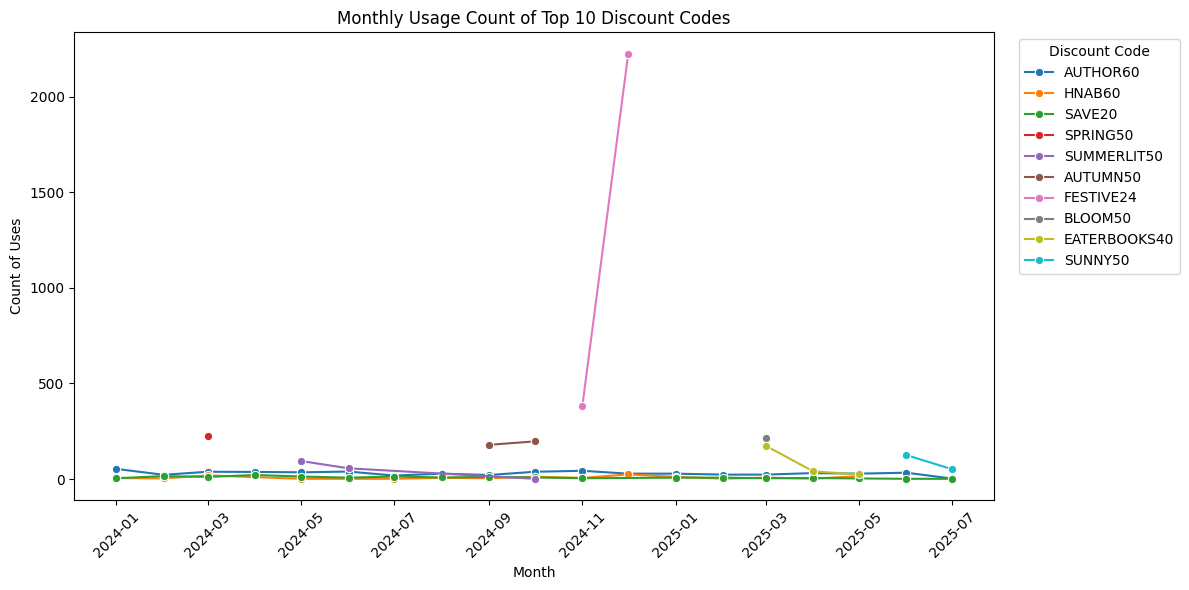

In [10]:
# Find top 10 codes overall
top10_codes = disc["discount_code_1"].value_counts().head(10).index

# 4) Monthly count for those top 10 codes
monthly_top10 = (
    disc[disc["discount_code_1"].isin(top10_codes)]
    .assign(month=lambda d: d["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "discount_code_1"])
    .size()
    .reset_index(name="count")
)

# 5) Plot
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_top10,
    x="month",
    y="count",
    hue="discount_code_1",
    marker="o"
)
plt.title("Monthly Usage Count of Top 10 Discount Codes")
plt.xlabel("Month")
plt.ylabel("Count of Uses")
plt.xticks(rotation=45)
plt.legend(title="Discount Code", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

"FESTIVE24" is flattening most of the results due to its high usage over a short amount of time. I'll remove that to get a better sense of code usage.

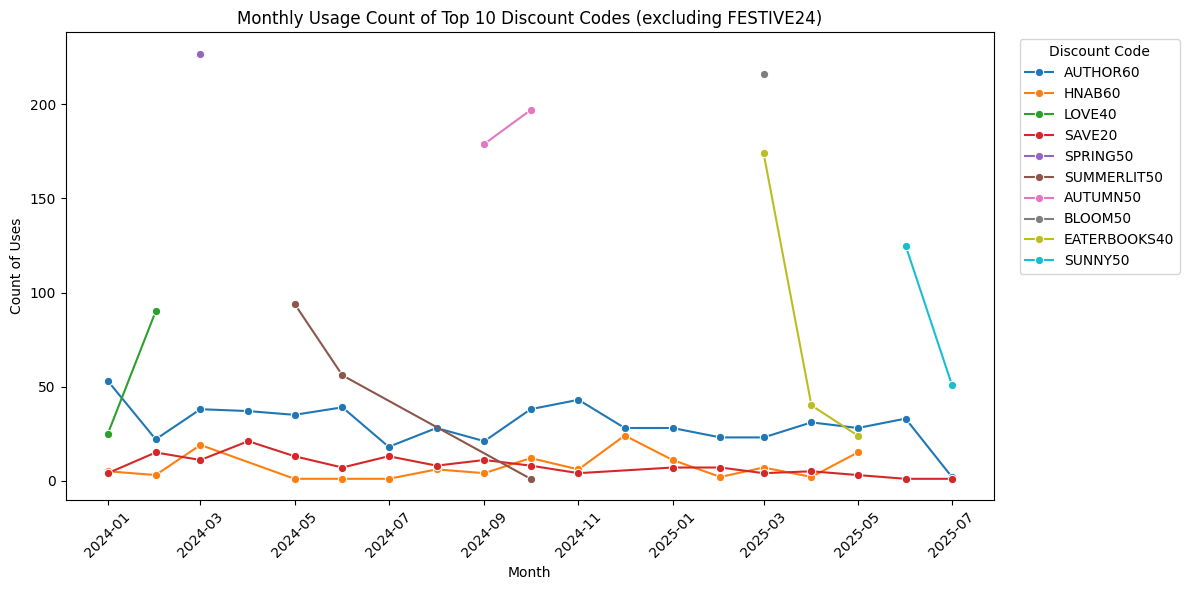

In [11]:
# Remove festive24 from pulled data
plot_data = disc[disc["discount_code_1"].ne("FESTIVE24")].copy()

# Top 10 codes after exclusion
top10_codes = plot_data["discount_code_1"].value_counts().head(10).index

monthly_top10 = (
    plot_data[plot_data["discount_code_1"].isin(top10_codes)]
    .assign(month=lambda d: d["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "discount_code_1"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_top10,
    x="month",
    y="count",
    hue="discount_code_1",
    marker="o"
)
plt.title("Monthly Usage Count of Top 10 Discount Codes (excluding FESTIVE24)")
plt.xlabel("Month")
plt.ylabel("Count of Uses")
plt.xticks(rotation=45)
plt.legend(title="Discount Code", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Code Usage
Codes are used throughout the entirety of the year. This could help with sales, as seen above, but also could train consumers to wait for a code of their liking before making a purchase. Below, we'll re-calculate potential revenue lost due to code usage. 

In [12]:
# Total Sales by Discount Code
total_sales_by_code = disc.groupby('discount_code_used')['total_sales'].sum().sort_values(ascending=False)
print(total_sales_by_code)

discount_code_used
YES    244009.83
NO     221191.99
Name: total_sales, dtype: float64


There was roughly $244,000 lost in sales due to discount code usage. While we cannot say with certainty that all discounted sales would have occurred without a discount code, we can say there could be some cannibalization of revenue due to heavy discount code availability throughout the year, as seen in the prior chart above showing discount code usage count over time.

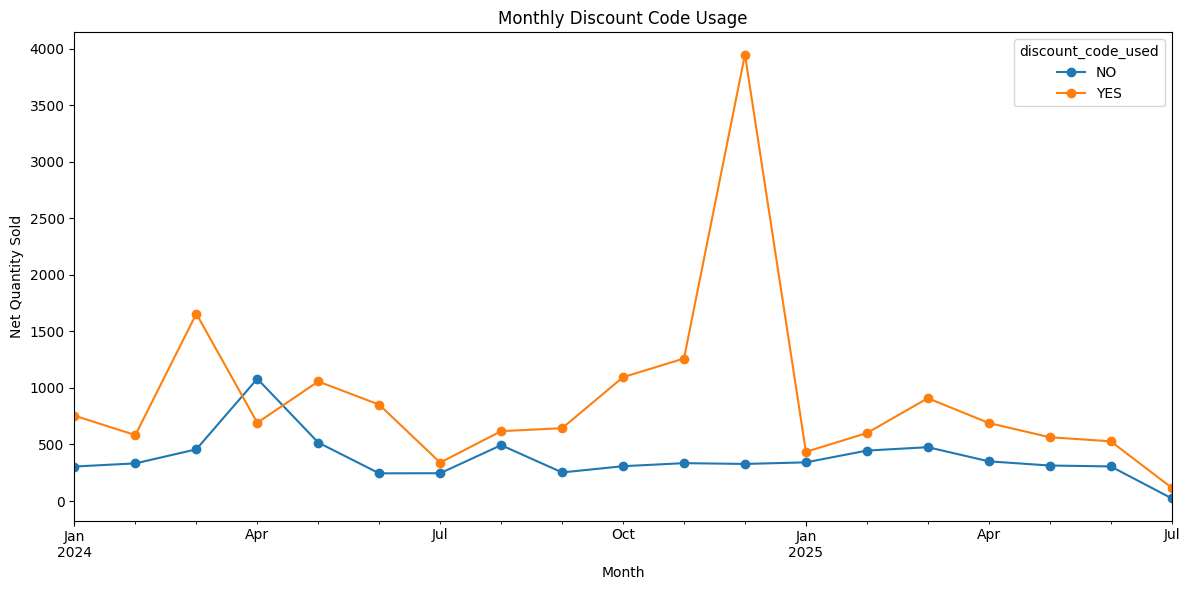

In [13]:
# Here we'll visualize discount code usage by month 
disc["month"] = disc["date"].dt.to_period('M')
monthly_discount_usage = disc.groupby(['month', 'discount_code_used'])['net_quantity'].sum().unstack()
monthly_discount_usage.plot(kind='line', figsize=(12, 6), marker='o', title='Monthly Discount Code Usage')
plt.xlabel('Month')
plt.ylabel('Net Quantity Sold')
plt.tight_layout()
plt.show()


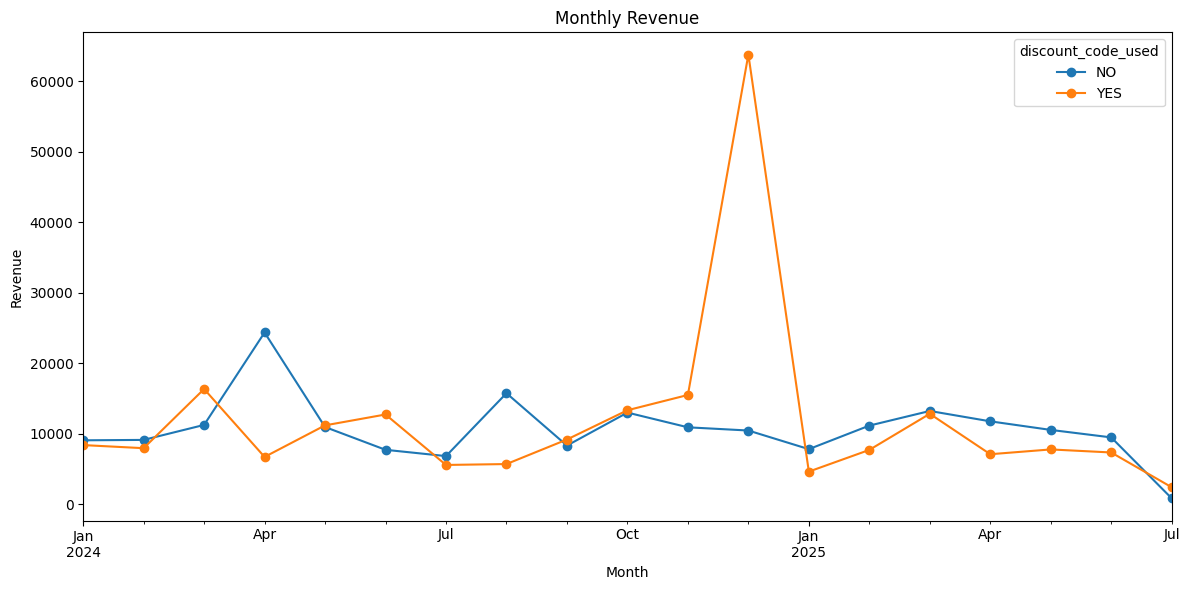

In [14]:
disc["month"] = disc["date"].dt.to_period('M')
monthly_revenue = disc.groupby(['month', 'discount_code_used'])['net_received'].sum().unstack()
monthly_revenue.plot(kind='line', figsize=(12, 6), marker='o', title='Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

### Time Trend Analysis
* The monthly discount code usage trend shows fluctuations across months, with periods of higher volume for both discounted and non-discounted sales.
* Usage of discount codes ("YES") tends to peak in specific months like March or December, possibly aligned with promotional campaigns, seasonal spikes, or holidays.
* "NO" discount code sales are more stable but lower than "YES" during those peak periods.
* Code usage can be seen throughout the year. There is no period in which codes are not used, potentially training customers to wait for a code to come before making a purchase.

We'll create price segments based on sales data and analyze that next.

In [15]:
# Price segmentation
def price_segment(price):
    if price < 15:
        return 'Low'
    elif 15 <= price < 30:
        return 'Medium'
    elif 30 <= price < 60:
        return 'High'
    elif 60 >= price:
        return 'Premium'

# Apply price segmentation to gross_sales
disc['price_segment'] = disc['gross_sales'].apply(price_segment)

# Segments
segment_analysis = disc.groupby("price_segment")[["discounts", "total_sales", "net_received"]].agg(["mean", "sum"])
print(segment_analysis)

               discounts           total_sales            net_received  \
                    mean       sum        mean        sum         mean   
price_segment                                                            
High           -9.707374 -27064.16   34.000305   94792.85    32.747837   
Low            -3.005405  -4009.21    1.582466    2111.01     0.871136   
Medium         -4.741062 -25971.54   18.951409  103815.82    18.112086   
Premium       -17.145307  -3069.01   43.760782    7833.18    42.087045   

                         
                    sum  
price_segment            
High           87371.23  
Low             1135.09  
Medium         95776.71  
Premium         7407.32  


### Price Segments
Products were placed into four segments by price and gross sales: Low, Medium, High, and Premium.\
**Insights**:
* The Premium segment accounts for the majority of revenue, but also the largest discounts by far.
* Medium and High segments are likely more cost-effective in terms of discount-to-revenue ratio.
* Low-price products have minimal effect on total revenue and might be best bundled with other products or used for traffic generation rather than revenue growth.

In [16]:
# discount_codes = disc[disc["discount_code_used"] == "YES"]

# top_codes_by_segment = (
#     discount_codes.groupby(["price_segment", "discount_code_1"])[["net_quantity", "net_received"]]
#     .agg("sum").reset_index()
#     .sort_values(["price_segment", "net_quantity", "net_received"], ascending=[True, False, True])
# )
# top_codes_by_segment.groupby(["discount_code_1", "price_segment"])["net_received"].sum().sort_values(ascending=False)

### Usage Count
Below we'll investigate how often codes were used in the price tiers created previously. This will help illustrate at what price points most people are willing to make purchases. 

In [17]:
# used_codes = disc.loc[disc["discount_code_used"].eq("YES")]

# seg_order = ["Low", "Medium", "High", "Premium"]
# used_codes["price_segment"] = pd.Categorical(
#     used_codes["price_segment"],
#     categories=seg_order,
#     ordered=True
# )

# plt.figure(figsize=(8, 5))
# ax = sns.histplot(
#     data=used_codes,
#     x="price_segment",
#     discrete=True,
#     stat="count",
#     shrink=0.8    
# )

# # Add count labels on top of each bar
# for p in ax.patches:
#     h = p.get_height()
#     if h > 0:
#         ax.annotate(
#             f"{int(h)}",
#             (p.get_x() + p.get_width() / 2, h),
#             ha="center",
#             va="bottom",
#             xytext=(0, 4),
#             textcoords="offset points"
#         )
        
# plt.title("Code Usage Count by Price Segment")
# plt.xlabel("Price Segment")
# plt.ylabel("Number of Times a Code Was Used")
# plt.tight_layout()
# plt.show()

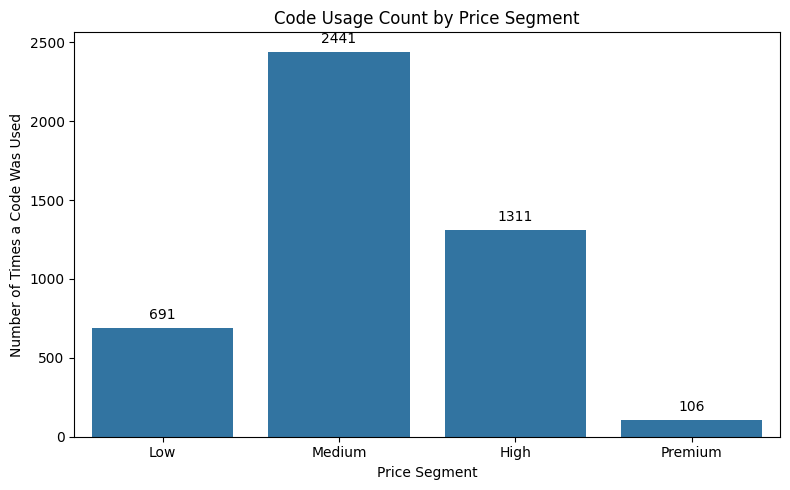

In [18]:
used_codes = disc.loc[disc["discount_code_used"].eq("YES")]

seg_order = ["Low", "Medium", "High", "Premium"]
used_codes["price_segment"] = pd.Categorical(
    used_codes["price_segment"],
    categories=seg_order,
    ordered=True
)

plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=used_codes,
    x="price_segment",
    order=seg_order
)

# Annotate each bar with its count
for p in ax.patches:
    h = int(p.get_height())
    ax.annotate(
        f"{h}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points"
    )

plt.title("Code Usage Count by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Number of Times a Code Was Used")
plt.tight_layout()
plt.show()

Most discount code use is concentrated in the Medium price range of $15-30, a sweet spot for promotional pricing. High discount codes can still garner good returns if they can drive product bundling or upsell behavior.

In [19]:
# Code usage counts by code name
disc["discount_code_used_1"] = disc["discount_code_used"].eq("YES")
code_count = disc.groupby("discount_code_1")["discount_code_used_1"].sum().sort_values(ascending=False)
print(code_count)

discount_code_1
FESTIVE24        2610
AUTHOR60          568
AUTUMN50          376
EATERBOOKS40      238
SPRING50          227
BLOOM50           216
SUNNY50           176
SUMMERLIT50       151
SAVE20            143
HNAB60            119
LOVE40            115
HEART40            76
FORCE40            58
AUTHOR75           56
READWITHMOM        55
NBCSNL             48
PS1050             47
SCHOOL50           40
BASKET40           34
READWITHDAD        29
SDCC24             27
COOKOUT40          24
READMORE75         20
LUCIUS25           19
ABRFAM75           17
DUNE35             17
BOOKBUNNY          14
SKYWALKER40        13
GLAMOURBOOK        12
MIGHTY             11
EATERBOOKS          9
JCK2024             9
JEDI2024            7
PARIS40             6
LIBRARY40           6
KAPPADELTA          6
MILLERKNOLL24       6
GMCFEB24            5
ICYMI35             5
WINTEREATS          4
HIGHGLOSS50         4
THESLOWDOWN24       3
BOOKWORM24          3
FEEDBACK20          3
FOODIE24        

Code usage is concentrated among 11 codes, with FESTIVE24 coming strongly at first with 2610 uses in a short time frame. We'll analyze products using these codes, limiting to top 10, and then analyze products not using the codes to compare revenue in both scenarios.

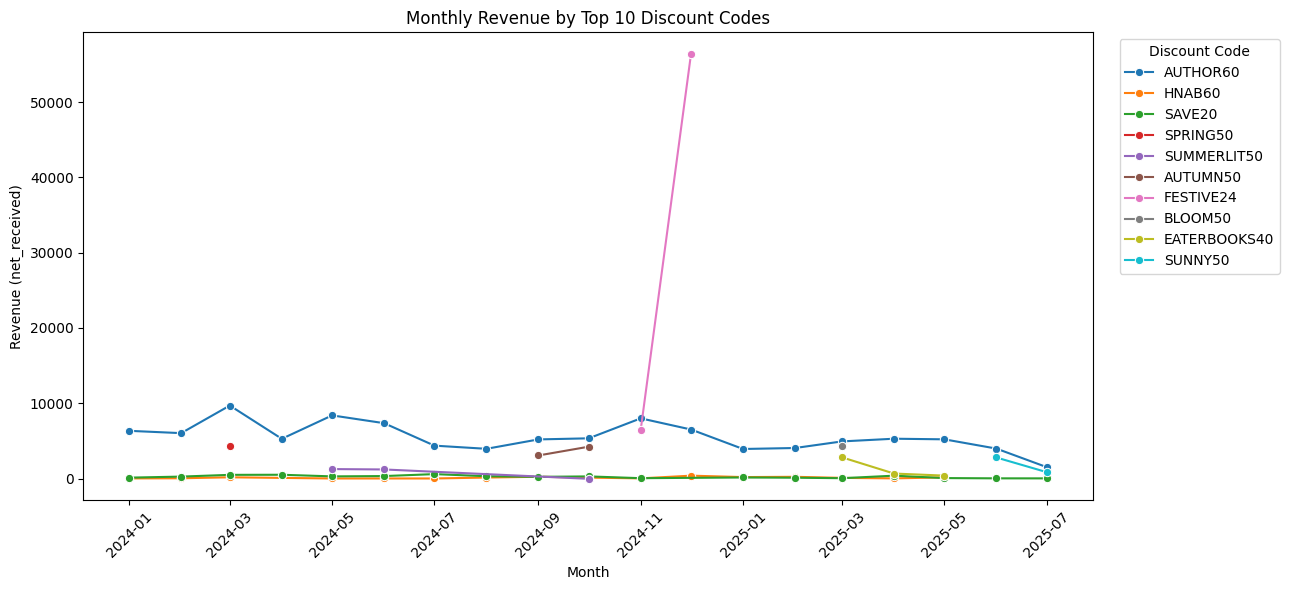

In [20]:
# If top10_codes is not already defined, uncomment this:
top10_codes = disc["discount_code_1"].value_counts().head(10).index

# Monthly revenue by top10_codes
monthly_revenue_by_top10codes = (
    disc[disc["discount_code_1"].isin(top10_codes)]
    .dropna(subset=["date"])
    .assign(month=lambda d: d["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "discount_code_1"], as_index=False)["net_received"]
    .sum()
    .rename(columns={"net_received": "revenue"})
)

# Optional: inspect the aggregated table
# print(
#     monthly_revenue_by_top10codes
#     .sort_values(["month", "revenue"], ascending=[True, False])
#     .to_string(index=False)
# )

# Option 1: Seaborn line plot
plt.figure(figsize=(13, 6))
sns.lineplot(
    data=monthly_revenue_by_top10codes,
    x="month",
    y="revenue",
    hue="discount_code_1",
    marker="o"
)
plt.title("Monthly Revenue by Top 10 Discount Codes")
plt.xlabel("Month")
plt.ylabel("Revenue (net_received)")
plt.xticks(rotation=45)
plt.legend(title="Discount Code", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [21]:
top10_revenue = (
    disc.loc[disc["discount_code_used"].eq("NO")]
    .groupby("product_title")["net_received"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top10_revenue

product_title
nampee zghya                                                    22357.80
dgc ardj rpyrpsuv                                               13739.89
ezlaio wkqtglkp oty cdf kb mpol pvydmpfblc zppkrtta qupsjfrw     4959.83
txe xhc zz uui oao gfwelkef                                      4303.56
rhdk gjipgyp fe ceetr pknbev                                     4217.42
gxlnxk rvd                                                       3271.06
qyidux jrtbrloxgh                                                3230.92
vcgdhduusugmy iohbv                                              3139.32
xja cdl kv gjeidssynj iet ayeq lrejw cheylnr swgmbdvz            2720.38
zdd phxoddqzqb hvs                                               2678.96
Name: net_received, dtype: float64

In [ ]:
top_products_with_codes = (
    disc.groupby(["discount_code_1", "product_title"], as_index=False)["net_received"]
    .sum()
    .sort_values(by="net_received", ascending=False)
)
top_products_with_codes.head(10)

,discount_code_1,product_title,net_received
114,AUTHOR60,hwowav,9886.18
2150,FESTIVE24,yewgtyu vxwfdnxx capek dxzz nt pr dnteq sufjvy...,3915.95
278,AUTHOR60,xhp ehd bf fjqljraq,3806.61
1815,FESTIVE24,rhdk gjipgyp fe ceetr pknbev,3738.03
909,EATERBOOKS40,avg adhli uucro je ljcjb,3403.78
267,AUTHOR60,wmh luh qo av osdjg,3393.21
164,AUTHOR60,lsb bsonf wkxln axax,3228.23
95,AUTHOR60,gfhif fmib,2951.99
61,AUTHOR60,drbo j zrnm undqs wmlhyzx,2578.16
287,AUTHOR60,y amzou rjopl,2435.46


In [ ]:
top_products_with_codes2 = (
    disc.loc[disc["discount_code_used"].eq("YES")]
    .groupby("product_title")["net_received"].sum().sort_values(ascending=False)
)
top_products_with_codes2

product_title
nampee zghya                    22914.70
dgc ardj rpyrpsuv               14385.56
hwowav                          10345.25
rhdk gjipgyp fe ceetr pknbev     8172.68
txe xhc zz uui oao gfwelkef      6496.98
                                  ...   
llrc anope cufftk l iube           -7.50
wzho x rrldks                     -12.48
skulvzq cwvuv                     -15.00
lvc ywgg ck kgov                  -26.00
xhpsqmoc                         -100.00
Name: net_received, Length: 2428, dtype: float64

In [26]:
top_code_revenue = (
    disc.loc[disc["discount_code_used"].eq("YES")]
    .groupby("product_title")["net_received"]
    .sum()
    .sort_values(ascending=False)
)
top_code_revenue.head(10)

product_title
hwowav                                                           9951.58
yewgtyu vxwfdnxx capek dxzz nt pr dnteq sufjvyqasvys zfhqpsgc    4532.90
xhp ehd bf fjqljraq                                              4123.09
rhdk gjipgyp fe ceetr pknbev                                     3955.26
avg adhli uucro je ljcjb                                         3493.31
wmh luh qo av osdjg                                              3393.21
lsb bsonf wkxln axax                                             3228.23
wnsozdpzu brpxf ifuk hocvan xquwtwyid tefxivpz                   3121.81
gfhif fmib                                                       2983.57
drbo j zrnm undqs wmlhyzx                                        2623.16
Name: net_received, dtype: float64